In [1]:
import GPy.kern
from censored_regressors.utils.oracle import Oracle, OracleGenerator,  RangeBoundGenerator, VariableBoundGenerator
from censored_regressors.losses.tobit_loss import RobustTobitLoss, GaussianNLLLoss
import numpy as np
import torch

from matplotlib import pyplot as plt

from censored_regressors.metrics import evaluators, metrics

In [2]:
import sys
import types

if 'imp' not in sys.modules:
    imp = types.ModuleType('imp')
    sys.modules['imp'] = imp
    # If the library uses specific functions from imp, you might need to mock them:
    imp.load_source = lambda *args: None

import climin

In [3]:
from censored_regressors.models.models_gpy import GP, TruncGP, CensoredGP_EP, CensoredGP_Laplace
from censored_regressors.models.models_gpytorch import GPyTorchOptimizer, CensoredGP_VI_gpytorch
from censored_regressors.models.censored_model_gpy import GPCensoredRegression
from censored_regressors.likelihoods.censored_likelihood_gpy import CensoredGaussian

In [4]:
oracle = Oracle.from_name('linear')

Loading Oracle for: $y = x + 1$


In [5]:
class LinearRegressionModel(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = torch.nn.Linear(in_features, out_features)  # Single input feature, single output

    def forward(self, x):
        return self.linear(x)

In [6]:
def optimise_lin_reg(model, x, y, loss_fn, c=None, num_iterations=1000, lr=0.05):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    # helper to ensure tensor
    def to_t(v): 
        if v is None: return None
        if not torch.is_tensor(v): 
            return torch.tensor(v, dtype=torch.float32)
        else:
            return v.float()
        # Ensure it is at least 2D (N, 1) if it's not empty
        if v.ndim == 1:
            v = v.view(-1, 1)
        return v

    x = to_t(x)
    y = to_t(y)
    c = to_t(c)
    
    if x.shape[0] != y.shape[0]:
        raise ValueError(f"Shape Mismatch! x has {x.shape[0]} samples, but y has {y.shape[0]}.")
    
    # If c is not provided, assume all data is observed (uncensored)
    if c is None:
        c = torch.zeros_like(y)
        
    if c.shape != y.shape:
        c = c.view_as(y)

    model.train()
    for epoch in range(num_iterations):
        optimizer.zero_grad()
        y_pred = model(x)
        
        # Loss calculation
        loss = loss_fn(mu_pred=y_pred, target=y, censorship=c)
        
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return {'model': model, 'losses': losses}

def train_and_predict(x, y, loss_fn, steps=1000, c=None):
    input_dim = 1
    if hasattr(x, 'shape') and len(x.shape) > 1:
        input_dim = x.shape[1]
    elif isinstance(x, list) and len(x) > 0 and isinstance(x[0], list):
         input_dim = len(x[0])

    print(f"Initializing Model with Input Dimension: {input_dim}")
        
    model = LinearRegressionModel(input_dim, 1)
    results = optimise_lin_reg(model, x, y, loss_fn, c, steps)
    
    model.eval()
    if not torch.is_tensor(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
    else:
        x_tensor = x.float()
        
    if input_dim == 1 and x_tensor.ndim == 1:
        x_tensor = x_tensor.view(-1, 1)
        
    with torch.no_grad():
        y_pred = model(x_tensor).cpu().numpy()
    
    return {
        'model': results['model'],
        'losses': results['losses'],
        'y_pred': y_pred
    }
        

gauss_loss = GaussianNLLLoss()
tobit_loss = RobustTobitLoss()

# Linear Model with Constant Bound

## Generate Data

In [7]:
gen = RangeBoundGenerator(
    oracle=oracle,
    n_samples=200,     # N = 200
    noise_scale=2.0,   # sigma_n = 2
    start=-10.0,       # x min
    end=10.0,          # x max
    censoring_low=-8, # No censoring specified in your snippet
    censoring_high=1
)

x, y, censoring, y_true = gen.generate()

In [8]:
# gen = RangeBoundGenerator(
#     oracle=oracle,
#     n_samples=200,     # N = 200
#     noise_scale=2.0,   # sigma_n = 2
#     start=-10.0,       # x min
#     end=10.0,          # x max
#     censoring_low=-8, # No censoring specified in your snippet
#     censoring_high=1
# )
# 
# x, y, censoring, y_true = gen.generate()

86


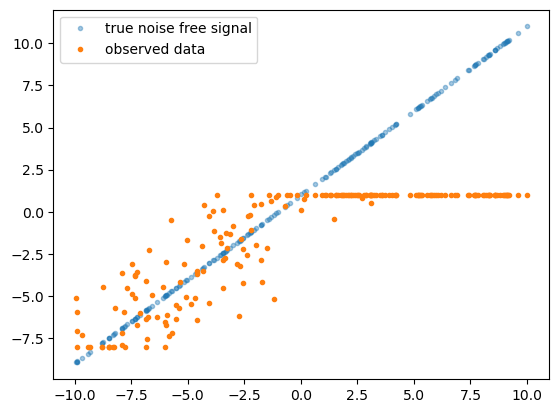

In [9]:
plt.plot(x, y_true, '.', alpha=0.4, label="true noise free signal")
plt.plot(x, y, '.', label="observed data")
print(censoring.sum())
plt.legend()

## Fit Maximum Likelihood

Initializing Model with Input Dimension: 1


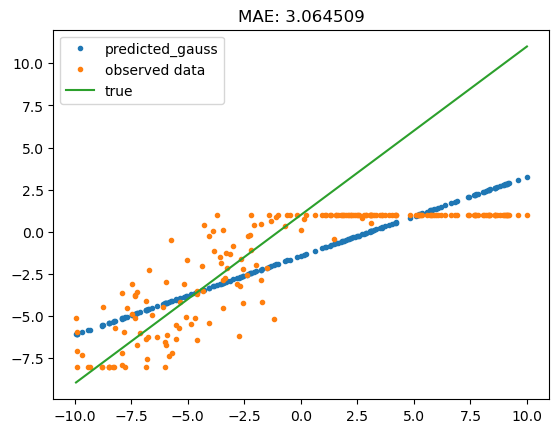

In [10]:
lm_all_data = train_and_predict(x, y, gauss_loss, 1000)
plt.plot(x, lm_all_data['y_pred'], '.', label='predicted_gauss')
plt.plot(x, y, '.', label='observed data')
plt.plot(x, y_true, '-', label='true')
plt.title("MAE: %s"%(evaluators.MAE(y_true, lm_all_data['y_pred'])))
plt.legend()

Initializing Model with Input Dimension: 1


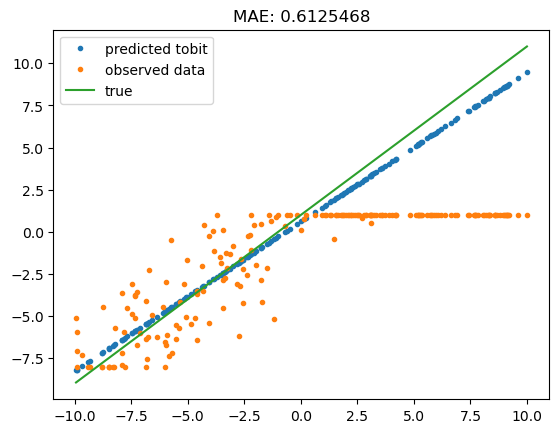

In [11]:
lm_all_data = train_and_predict(x, y, tobit_loss, 1000, censoring)
plt.plot(x, lm_all_data['y_pred'], '.', label='predicted tobit')
plt.plot(x, y, '.', label='observed data')
plt.plot(x, y_true, '-', label='true')
plt.title("MAE: %s"%(evaluators.MAE(y_true, lm_all_data['y_pred'])))
plt.legend()

## Bayesian Linear Model

In [12]:
def visualise_gp(pred, title):
    mu = pred['f_mean']
    lower = pred['f_025']
    upper = pred['f_975']
    
    plt.plot(x, y, '.', label='observed data')
    plt.plot(x, y_true, '-', label='true')
    
    plt.plot(x, mu, 'b-', lw=2, label='GP Mean')
    plt.fill_between(x.flatten(), lower.flatten(), upper.flatten(), color='b', alpha=0.2, label='95% CI')
    
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

reconstraining parameters GP_regression.Gaussian_noise.variance


Observed data metrics:
{'NLPD': 2.2296211942688005, 'NLPD_c': 2.2427164959737724, 'NLPD_nc': 2.212954446644291, 'RMSE': 2.2523045584364074, 'MAE': 1.816658474207896, 'MAE_c': 1.8423506670519088, 'MAE_nc': 1.7839593196791528, 'Hinge_MAE': 1.1270568198705953, 'Coverage': 0.445, 'Accuracy': 0.825, 'Precision': 1.0, 'Recall': 0.6875, 'Jaccard': 0.6875}
Latent data metrics:
{'NLPD_latent': 2.666282097861207, 'NLPD_c_latent': 3.0971114404353406, 'NLPD_nc_latent': 2.117953843675947, 'RMSE': 3.094856021755744, 'MAE': 2.640595994923929, 'MAE_c': 3.426041970862489, 'MAE_nc': 1.6409374800930328, 'Hinge_MAE': 1.1270568198705953, 'Coverage': 0.02, 'Accuracy': 0.825, 'Precision': 1.0, 'Recall': 0.6875, 'Jaccard': 0.6875}


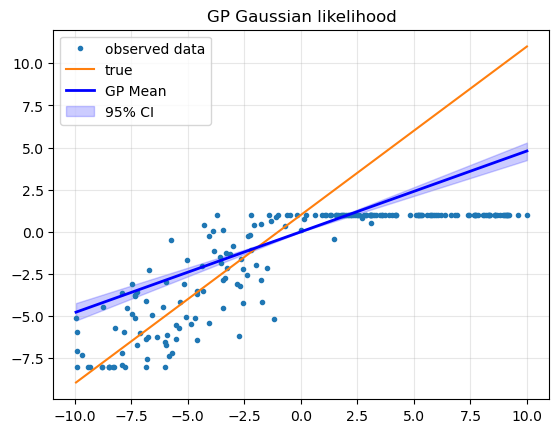

In [13]:
model_gp = GP('lin')
model_gp.fit((x, y, censoring))
pred = model_gp.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_gp))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_gp))
visualise_gp(pred, 'GP Gaussian likelihood')

reconstraining parameters gp_censored_regression.CensoredGaussian.variance


Observed data metrics:
{'NLPD': 1.1419743, 'NLPD_c': 0.41937286, 'NLPD_nc': 2.061649, 'RMSE': 3.072773084387096, 'MAE': 2.3773937944077264, 'MAE_c': 3.0005117844833697, 'MAE_nc': 1.5843345343114528, 'Hinge_MAE': 0.8417583349054913, 'Coverage': 0.5, 'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'Jaccard': 0.7857142857142857}
Latent data metrics:
{'NLPD_latent': 1.8308629051832803, 'NLPD_c_latent': 1.9644920361358305, 'NLPD_nc_latent': 1.6607894657891256, 'RMSE': 1.2974050964510973, 'MAE': 1.0442348513670034, 'MAE_c': 1.544948035293544, 'MAE_nc': 0.40696352636958794, 'Hinge_MAE': 0.8417583349054913, 'Coverage': 0.295, 'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'Jaccard': 0.7857142857142857}


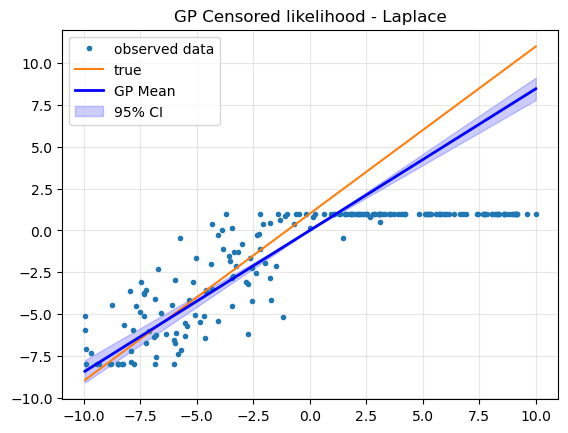

In [14]:
model_la = CensoredGP_Laplace('lin')
model_la.fit((x, y, censoring))
pred = model_la.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'],  censoring, model_la))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_la))
visualise_gp(pred, 'GP Censored likelihood - Laplace')

In [15]:
import GPy
from GPy.inference.latent_function_inference import Laplace

kernel = GPy.kern.Linear(input_dim=1)
gp = GPCensoredRegression(X=x.reshape(-1, 1), Y=y.reshape(-1, 1),
                          censoring=censoring.reshape(-1), kernel=kernel,
                          likelihood=CensoredGaussian(censoring=censoring, variance=0.1),
                          inference_method=Laplace())

[gp.optimize(optimizer="BFGS", max_iters=1000, messages=True), gp.optimize(optimizer="BFGS", max_iters=1000, messages=True)]

Observed data metrics:
{'NLPD': 1.1419704, 'NLPD_c': 0.4194573, 'NLPD_nc': 2.0615325, 'RMSE': 3.0751144173382947, 'MAE': 2.378889183897664, 'MAE_c': 3.002559988266399, 'MAE_nc': 1.5851263419738186, 'Hinge_MAE': 0.841825998350773, 'Coverage': 0.5, 'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'Jaccard': 0.7857142857142857}
Latent data metrics:
{'NLPD_latent': 1.8306150771328646, 'NLPD_c_latent': 1.9644357111653952, 'NLPD_nc_latent': 1.6602979065460075, 'RMSE': 1.2952124182195814, 'MAE': 1.042605421939286, 'MAE_c': 1.5419615212575475, 'MAE_nc': 0.40706129553422604, 'Hinge_MAE': 0.841825998350773, 'Coverage': 0.295, 'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'Jaccard': 0.7857142857142857}


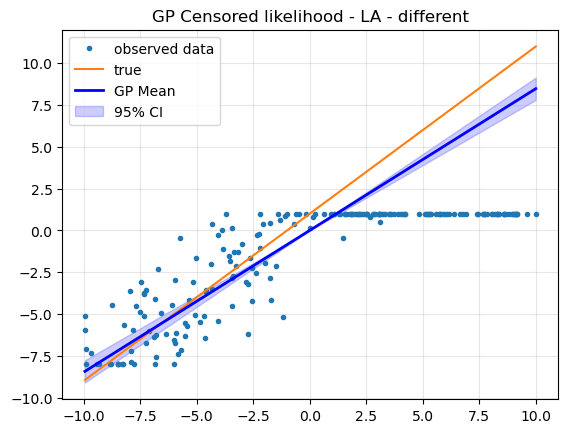

In [16]:
f_samples = gp.posterior_samples_f(X=x, size=10000)
f_mean = np.mean(f_samples, axis=2)
f_025 = np.quantile(a=f_samples, q=0.025, axis=2).reshape(-1,)
f_975 = np.quantile(a=f_samples, q=0.975, axis=2).reshape(-1,)

pred = {'f_mean': f_mean, 'f_025': f_025, 'f_975': f_975}
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, gp))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, gp))
visualise_gp(pred, 'GP Censored likelihood - LA - different')

reconstraining parameters gp_censored_regression.CensoredGaussian.variance
reconstraining parameters gp_censored_regression.CensoredGaussian.variance


Observed data metrics:
{'NLPD': 2.1801658, 'NLPD_c': 1.005256, 'NLPD_nc': 3.6755052, 'RMSE': 2.861253297324602, 'MAE': 2.242645392380279, 'MAE_c': 2.810161854655194, 'MAE_nc': 1.5203517131212962, 'Hinge_MAE': 0.8411538122455191, 'Coverage': 0.465, 'Accuracy': 0.875, 'Precision': 1.0, 'Recall': 0.7767857142857143, 'Jaccard': 0.7767857142857143}
Latent data metrics:
{'NLPD_latent': 2.7770835097485316, 'NLPD_c_latent': 4.241768348050037, 'NLPD_nc_latent': 0.9129391700920703, 'RMSE': 1.5259142813163118, 'MAE': 1.2314558690413935, 'MAE_c': 1.8321736196196186, 'MAE_nc': 0.46690600466910703, 'Hinge_MAE': 0.8411538122455191, 'Coverage': 0.06, 'Accuracy': 0.875, 'Precision': 1.0, 'Recall': 0.7767857142857143, 'Jaccard': 0.7767857142857143}


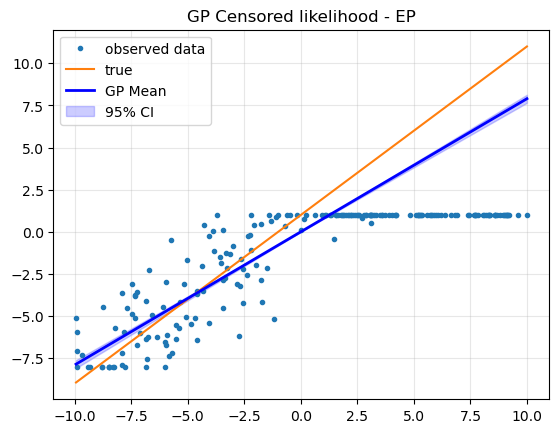

In [17]:
model_ep = CensoredGP_EP('lin')
model_ep.fit((x, y, censoring))
pred = model_ep.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_ep))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_ep))
visualise_gp(pred, 'GP Censored likelihood - EP')

Fitting CensoredGP_VI with ADAM (Restarts: 5, Init: empirical)...
  [Restart 1] Attempting Empirical Initialization...
  [!] Empirical Init failed: Kernel has no lengthscale.
  [!] Initialization failed. Falling back to random initialization.


 /Users/bromia/miniconda3/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning:A not p.d., added jitter of 1.0e-08 to the diagonal
 /Users/bromia/projects/censored_regressors/src/censored_regressors/metrics/metrics.py:220: UserWarning:GPyTorch NLPD failed: The size of tensor a (112) must match the size of tensor b (200) at non-singleton dimension 1
 /Users/bromia/projects/censored_regressors/src/censored_regressors/metrics/metrics.py:220: UserWarning:GPyTorch NLPD failed: The size of tensor a (88) must match the size of tensor b (200) at non-singleton dimension 1


Observed data metrics:
{'NLPD': 1.1750216926771797, 'NLPD_c': nan, 'NLPD_nc': nan, 'RMSE': 3.0210318815222066, 'MAE': 2.34419970975284, 'MAE_c': 2.9548523851431656, 'MAE_nc': 1.567005395619699, 'Hinge_MAE': 0.8403362410103091, 'Coverage': 0.57, 'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'Jaccard': 0.7857142857142857}
Latent data metrics:
{'NLPD_latent': 27.32923890906838, 'NLPD_c_latent': 86.00064364859229, 'NLPD_nc_latent': 1813.3737976531768, 'RMSE': 1.3475800760610066, 'MAE': 1.0812468897643999, 'MAE_c': 1.6113575614411995, 'MAE_nc': 0.4065605803575641, 'Hinge_MAE': 0.8403362410103091, 'Coverage': 0.36, 'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'Jaccard': 0.7857142857142857}


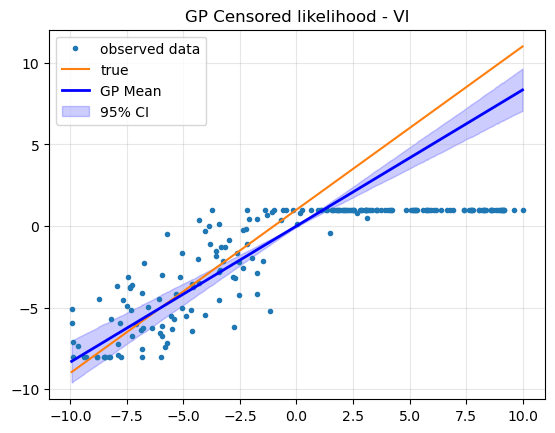

In [18]:
model_vi = CensoredGP_VI_gpytorch('lin')
model_vi.fit((x, y, censoring), optimizer='adam', num_restarts=5, init_params='empirical')
pred = model_vi.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_vi))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_vi))
visualise_gp(pred, 'GP Censored likelihood - VI')

Fitting CensoredGP_VI with NGD (Restarts: 3, Init: empirical)...
  [Restart 1] Attempting Empirical Initialization...
  [!] Empirical Init failed: Kernel has no lengthscale.
  [!] Initialization failed. Falling back to random initialization.


 /Users/bromia/miniconda3/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning:A not p.d., added jitter of 1.0e-08 to the diagonal
 /Users/bromia/projects/censored_regressors/src/censored_regressors/metrics/metrics.py:220: UserWarning:GPyTorch NLPD failed: The size of tensor a (112) must match the size of tensor b (200) at non-singleton dimension 1
 /Users/bromia/projects/censored_regressors/src/censored_regressors/metrics/metrics.py:220: UserWarning:GPyTorch NLPD failed: The size of tensor a (88) must match the size of tensor b (200) at non-singleton dimension 1


Observed data metrics:
{'NLPD': 1.144575815109046, 'NLPD_c': nan, 'NLPD_nc': nan, 'RMSE': 3.0514106775580734, 'MAE': 2.3637528448864344, 'MAE_c': 2.981956849450986, 'MAE_nc': 1.5769477481679146, 'Hinge_MAE': 0.8409931762983617, 'Coverage': 0.49, 'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'Jaccard': 0.7857142857142857}
Latent data metrics:
{'NLPD_latent': 65.4275495557498, 'NLPD_c_latent': 347.8513315178126, 'NLPD_nc_latent': 6028.980372167463, 'RMSE': 1.3174682352949127, 'MAE': 1.0590344578551787, 'MAE_c': 1.5718221101836554, 'MAE_nc': 0.4063956276189359, 'Hinge_MAE': 0.8409931762983617, 'Coverage': 0.295, 'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'Jaccard': 0.7857142857142857}


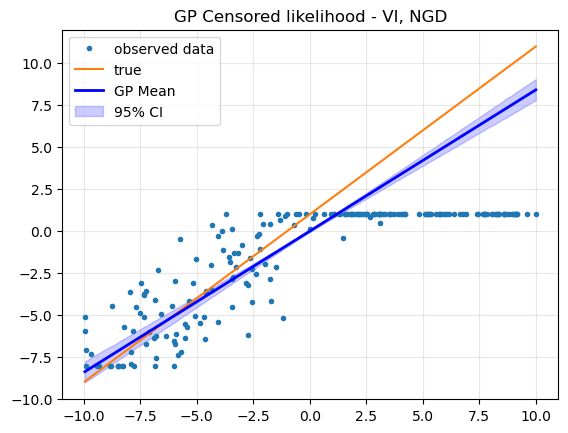

In [22]:
model_vi2 = CensoredGP_VI_gpytorch('lin')
model_vi2.fit((x, y, censoring), optimizer='ngd', init_params='empirical')
pred = model_vi2.predict(x)
model_vi2.model.eval()
model_vi2.likelihood.eval()

print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'],  censoring, model_vi2, model_vi2.likelihood.eval()))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_vi2, model_vi2.likelihood.eval()))
visualise_gp(pred, 'GP Censored likelihood - VI, NGD')

In [ ]:
model_vi3.likelihood.state_dict()

In [ ]:
model_vi3 = CensoredGP_VI_gpytorch('lin')
model_vi3.fit((x, y, censoring), init_params='gpy')
pred = model_vi3.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_vi3))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_vi3))
visualise_gp(pred, 'GP Censored likelihood - VI + LA, NGD')

In [ ]:
import torch
import gpytorch
import numpy as np

def diagnose_nlpd(model, X, y_true, likelihood=None):
    """
    Step-by-step diagnostic for GPyTorch NLPD calculation.
    """
    print("\n" + "="*60)
    print("STARTING NLPD DIAGNOSTIC")
    print("="*60)

    # 1. Setup & Type Checks
    torch_model = model.model if hasattr(model, 'model') else model
    if likelihood is None:
        likelihood = getattr(model, 'likelihood', getattr(torch_model, 'likelihood', None))
    
    torch_model.eval()
    if likelihood: likelihood.eval()

    # Move to CPU for safer debugging
    device = torch.device('cpu')
    dtype = torch.float32

    # Prepare Data
    X_torch = torch.as_tensor(X, device=device, dtype=dtype)
    y_torch = torch.as_tensor(y_true, device=device, dtype=dtype).squeeze()
    
    print(f"[1] Data Prepared. X: {X_torch.shape}, y: {y_torch.shape}")
    print(f"    y range: [{y_torch.min().item():.4f}, {y_torch.max().item():.4f}]")
    if torch.isnan(y_torch).any():
        print("    !!! CRITICAL: Input y_true contains NaNs!")
        return

    # 2. Forward Pass (Latent Distribution)
    print("\n[2] Running Forward Pass (q_f)...")
    try:
        with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-3):
            q_f = torch_model(X_torch)
            
            means = q_f.mean
            vars = q_f.variance
            
            print(f"    q_f.mean range: [{means.min().item():.4f}, {means.max().item():.4f}]")
            print(f"    q_f.variance range: [{vars.min().item():.4f}, {vars.max().item():.4f}]")
            
            if torch.isnan(means).any():
                print("    !!! CRITICAL: q_f.mean contains NaNs! Model is broken.")
                return
            if (vars <= 0).any():
                print("    !!! CRITICAL: q_f.variance contains non-positive values!")
                
    except Exception as e:
        print(f"    !!! CRITICAL: Forward pass crashed: {e}")
        return

    # 3. Likelihood Logic Check
    print("\n[3] Checking Likelihood Logic...")
    is_censored = hasattr(likelihood, 'log_prob_density')
    print(f"    Has 'log_prob_density' method? {is_censored}")
    
    if not is_censored:
        print("    -> Using Standard Gaussian (Marginal) Logic.")
        # ... (Standard logic code omitted for brevity as your issue is Censored) ...
        return

    # 4. Monte Carlo Sampling (The likely failure point)
    print("    -> Using Censored/Monte Carlo Logic.")
    num_samples = 1000
    
    try:
        # Sample f
        f_samples = q_f.sample(torch.Size([num_samples]))
        print(f"    Sampled f shape: {f_samples.shape}")
        if torch.isnan(f_samples).any():
            print("    !!! CRITICAL: f_samples contains NaNs. Cholesky likely failed implicitly.")
            return

        # 5. Compute Log Prob Density
        print("\n[4] Computing log_prob_density(f, y)...")
        log_lik_samples = likelihood.log_prob_density(f_samples, y_torch)
        
        # --- DEEP DIVE INTO LOG LIKELIHOODS ---
        nan_count = torch.isnan(log_lik_samples).sum().item()
        inf_count = torch.isinf(log_lik_samples).sum().item()
        neg_inf_count = (log_lik_samples == float('-inf')).sum().item()
        pos_inf_count = (log_lik_samples == float('inf')).sum().item()
        
        print(f"    log_lik_samples stats:")
        print(f"      - Total elements: {log_lik_samples.numel()}")
        print(f"      - NaNs:     {nan_count}  <-- IF > 0, THIS IS THE BUG")
        print(f"      - -Infs:    {neg_inf_count} (Prob = 0)")
        print(f"      - +Infs:    {pos_inf_count}")
        print(f"      - Max val:  {log_lik_samples.max().item()}")
        print(f"      - Min val:  {log_lik_samples.min().item()}")

        if nan_count > 0:
            print("\n    !!! DIAGNOSIS: The likelihood function returned NaNs.")
            print("    This usually happens in censored likelihoods when:")
            print("    1. 'phi(z)' or 'Phi(z)' encounters extreme z-scores.")
            print("    2. Log of zero (log(0)) or Log of negative numbers occurred.")
            return

        # 6. LogSumExp
        print("\n[5] Performing LogSumExp...")
        S = torch.tensor(num_samples, device=device, dtype=dtype)
        
        # Check per-point results before averaging
        lpd_per_point = torch.logsumexp(log_lik_samples, dim=0) - torch.log(S)
        
        print(f"    LPD per point range: [{lpd_per_point.min().item()}, {lpd_per_point.max().item()}]")
        
        # Check for -inf in final result (means ALL samples were impossible)
        bad_points = torch.isinf(lpd_per_point)
        if bad_points.any():
            print(f"    !!! WARNING: {bad_points.sum().item()} test points have -inf LPD.")
            print("    This means the model says these events are IMPOSSIBLE (Prob=0).")
            print("    This drives the Mean NLPD to Inf.")

        nlpd = -lpd_per_point.mean().item()
        print(f"\n[6] Final NLPD Result: {nlpd}")
        
    except Exception as e:
        print(f"\n!!! CRITICAL ERROR during Monte Carlo step: {e}")
        import traceback
        traceback.print_exc()

diagnose_nlpd(model_vi.model, x, y, model_vi.likelihood)
# ==========================================================

# Linear Model with Variable Bound

In [ ]:
def variable_bound(x, y, bound_slope = 0.4):
    lower_bound = -bound_slope * x - 2.0
    upper_bound = -0.5 * bound_slope * x + 4.0
    return lower_bound, upper_bound

gen2 = VariableBoundGenerator(oracle, 
                              start=-10.0,       # x min
                              end=10.0,          # x max
                              n_samples=200, noise_scale=1., 
                              bounds_generator=variable_bound)
x, y, censoring, y_true = gen2.generate()

In [ ]:
plt.plot(x, y_true, '.', alpha=0.4, label="true noise free signal")
plt.plot(x, y, '.', label="observed data")
print(censoring.sum())
plt.legend()

In [ ]:
lm_all_data = train_and_predict(x, y, gauss_loss, 1000)
plt.plot(x, lm_all_data['y_pred'], '.', label='predicted_gauss')
plt.plot(x, y, '.', label='observed data')
plt.plot(x, y_true, '-', label='true')
plt.legend()

In [ ]:
lm_all_data = train_and_predict(x, y, tobit_loss, 1000, censoring)
plt.plot(x, lm_all_data['y_pred'], '.', label='predicted tobit')
plt.plot(x, y, '.', label='observed data')
plt.plot(x, y_true, '-', label='true')
plt.legend()

In [ ]:
model_gp = GP('lin')
model_gp.fit((x, y, censoring))
pred = model_gp.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_gp))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_gp))
visualise_gp(pred, 'GP Gaussian likelihood')

In [ ]:
model_la = CensoredGP_Laplace('lin')
model_la.fit((x, y, censoring))
pred = model_la.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_la))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_la))
visualise_gp(pred, 'GP Censored likelihood - Laplace')

In [ ]:
model_vi = CensoredGP_VI_gpytorch('lin')
model_vi.fit((x, y, censoring), init_params='empirical') 
pred = model_vi.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_vi))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_vi))
visualise_gp(pred, 'GP Censored likelihood - VI, NGD')

In [ ]:
model_vi2 = CensoredGP_VI_gpytorch('lin')
model_vi2.fit((x, y, censoring), init_params='gpy')
pred = model_vi2.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_vi2))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_vi2))
visualise_gp(pred, 'GP Censored likelihood - VI + LA, NGD')

In [ ]:
model_ep = CensoredGP_EP('lin')
model_ep.fit((x, y, censoring))
pred = model_ep.predict(x)
print("Observed data metrics:")
print(evaluators.evaluate_observed(x, y, pred['f_mean'],  pred['f_025'], pred['f_975'], censoring, model_ep))
print("Latent data metrics:")
print(evaluators.evaluate_latent(x, y, y_true, pred['f_mean'], pred['f_025'], pred['f_975'], censoring, model_ep))
visualise_gp(pred, 'GP Censored likelihood - EP')